### Importing Libraries

In [191]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error,mean_squared_error

### Loading the dataset

In [192]:
df=pd.read_csv('concrete_data.csv')


In [193]:
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [195]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [196]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [197]:
df.duplicated().sum()

25

### Separate features and target

In [198]:
X=df.drop(columns='concrete_compressive_strength')
y=df['concrete_compressive_strength']

### Outlier detection

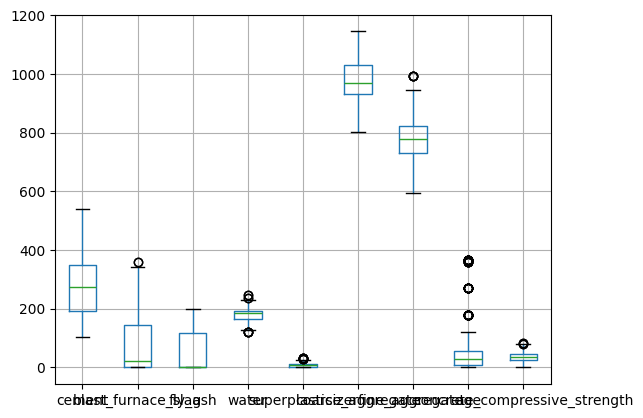

In [199]:
df.boxplot()
plt.show()

In [200]:
z = zscore(df)
outliers = (abs(z) > 3)
outliers

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [201]:
print(outliers.sum())

49


In [202]:
outlier_count = pd.DataFrame(outliers, columns=df.columns).sum()
print(outlier_count)

cement                            0
blast_furnace_slag                4
fly_ash                           0
water                             2
superplasticizer                 10
coarse_aggregate                  0
fine_aggregate                    0
age                              33
concrete_compressive_strength     0
dtype: int64


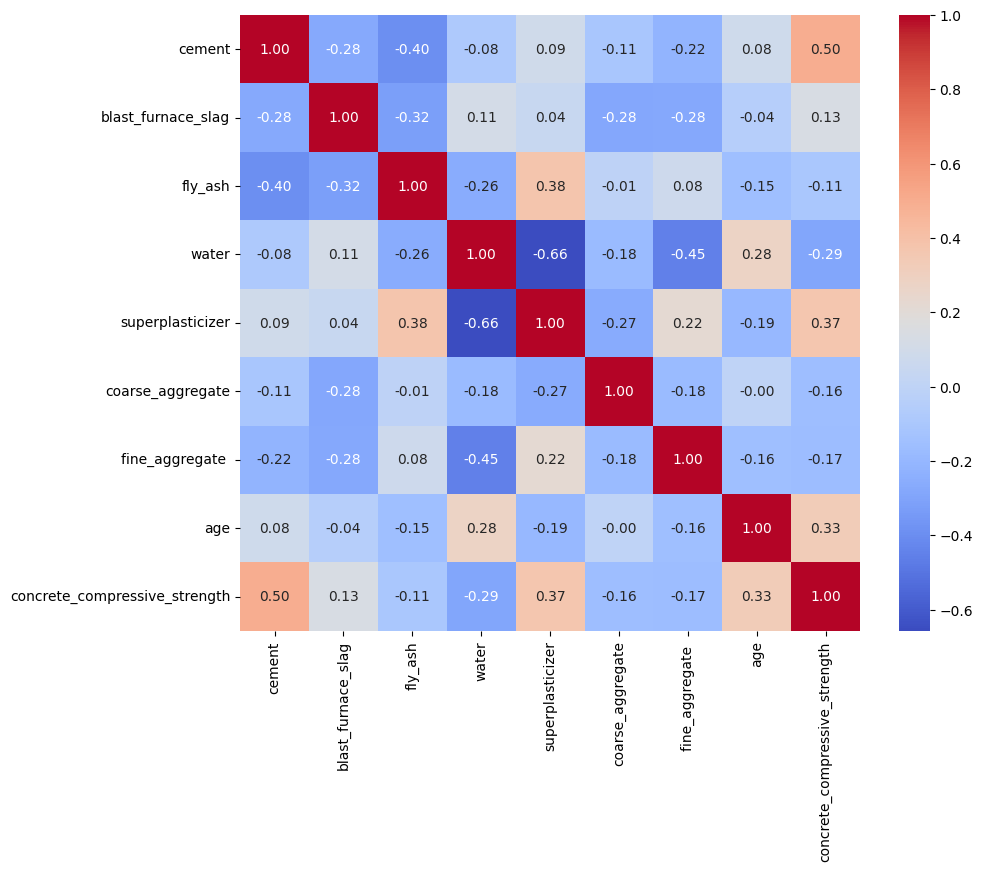

In [203]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt=".2f")
plt.show()

### Train-test split

In [204]:
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

### Scaling

In [205]:
scaler=StandardScaler()
updated_Xtrain=scaler.fit_transform(Xtrain)

In [206]:
updated_Xtest=scaler.transform(Xtest)

### Model training

In [207]:
model=LinearRegression()
model.fit(updated_Xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [208]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef.sort_values("Coefficient", ascending=False))

              Feature  Coefficient
0              cement    12.788413
1  blast_furnace_slag     9.434456
7                 age     7.037434
2             fly_ash     5.254578
6     fine_aggregate      1.950529
4    superplasticizer     1.852126
5    coarse_aggregate     1.405196
3               water    -2.882597


### Prediction

In [209]:
pred_ytrain=model.predict(updated_Xtrain)
pred_ytest=model.predict(updated_Xtest)

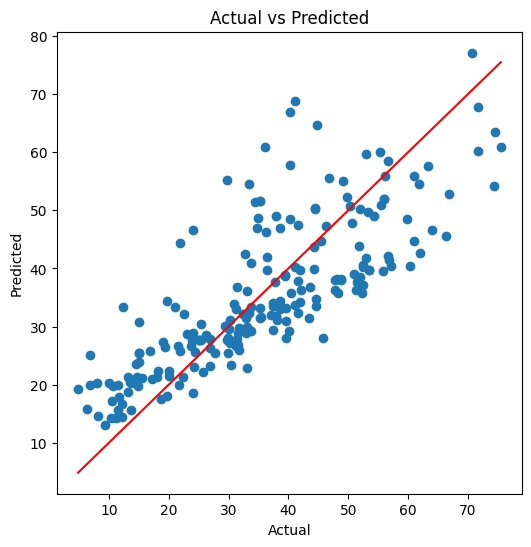

In [210]:
plt.figure(figsize=(6,6))
plt.scatter(ytest, pred_ytest)

plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

### model evaluation

In [211]:
print('Train Result')
print('r2_score: ',r2_score(ytrain,pred_ytrain))
print('MAE: ',mean_absolute_error(ytrain,pred_ytrain))
print('RMSE: ',root_mean_squared_error(ytrain,pred_ytrain))
print("MSE:", mean_squared_error(ytrain, pred_ytrain))

Train Result
r2_score:  0.6105238047649741
MAE:  8.330108766506683
RMSE:  10.518787334819802
MSE: 110.64488699516545


In [212]:
print('Test Result')
print('r2_score: ',r2_score(ytest,pred_ytest))
print('MAE: ',mean_absolute_error(ytest,pred_ytest))
print('RMSE: ',root_mean_squared_error(ytest,pred_ytest))
print("MSE:", mean_squared_error(ytest, pred_ytest))


Test Result
r2_score:  0.627553179231485
MAE:  7.7455592439214325
RMSE:  9.796475901624358
MSE: 95.9709400911068


### Conclusion:

The Linear Regression model achieved an R² score of 0.628 on the test data, indicating that it explains approximately 62.8% of the variance in concrete compressive strength. The training and testing R² scores are very similar, suggesting that the model generalizes well and does not exhibit significant overfitting. The Mean Absolute Error (MAE) of 7.75 indicates that the model's predictions are, on average, about 7.75 units away from the actual values. The RMSE of 9.80 is only moderately higher than the MAE, suggesting that there are no substantial large prediction errors. Overall, the model provides a reasonable baseline for predicting concrete compressive strength, though there is room for improvement through feature engineering or more advanced regression techniques.